Data path: /Users/sreeragm/fraud-decision-engine/data/creditcard.csv
Reports path: /Users/sreeragm/fraud-decision-engine/reports

Dataset shape: (284807, 31)

TEMPORAL SPLIT
Train      : (199364, 31)
Validation : (42721, 31)
Test       : (42722, 31)

ORIGINAL TRAINING CLASS DISTRIBUTION
Class
0    198980
1       384
Name: count, dtype: int64

Fraud rate: 0.0019261250777472363

Class weight:
scale_pos_weight = 518.1770833333334

Training Model A — Class Weighted XGBoost...
Model A complete.

APPLYING SMOTE

Before SMOTE:
Class
0    198980
1       384
Name: count, dtype: int64

After SMOTE:
Class
0    198980
1    198980
Name: count, dtype: int64

Original training rows: 199364
SMOTE training rows   : 397960

Validation rows: 42721
Test rows: 42722

Training Model B — SMOTE XGBoost...
Model B complete.

SMOTE VS CLASS WEIGHTING
                 Model    Dataset   PR_AUC  ROC_AUC  Precision   Recall       F1  Alerts
Class Weighted XGBoost Validation 0.861824 0.988541   0.914894 0.767857 0.

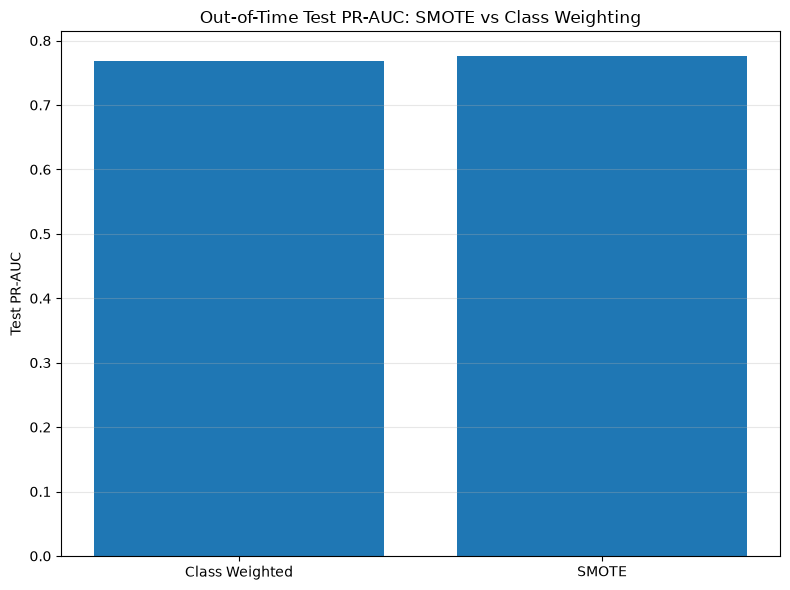

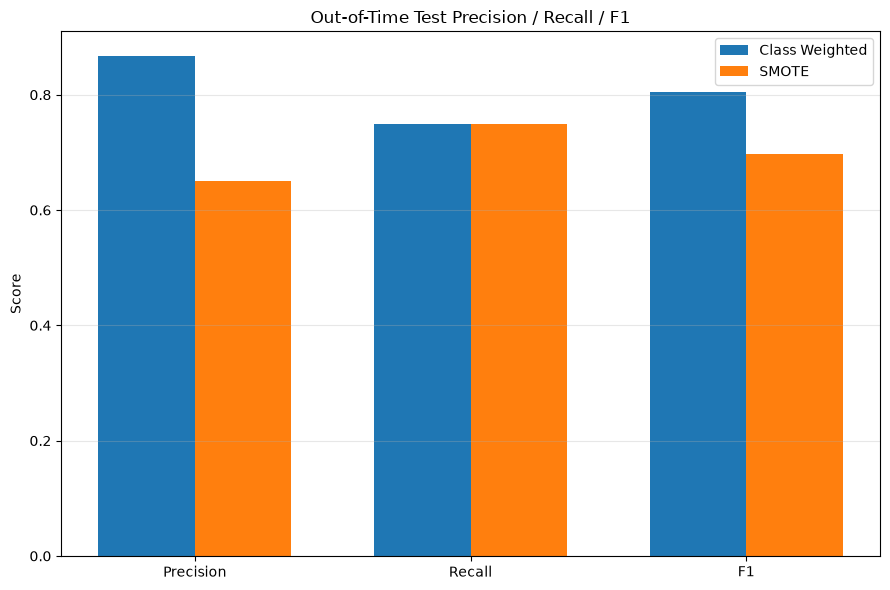


BEST TEST F1 THRESHOLDS

Class Weighted XGBoost
Threshold : 0.87
Precision : 0.9512
Recall    : 0.7500
F1        : 0.8387
Alerts    : 41

SMOTE XGBoost
Threshold : 0.98
Precision : 0.9750
Recall    : 0.7500
F1        : 0.8478
Alerts    : 40

Saved: ../reports/smote_vs_weighted_thresholds.csv


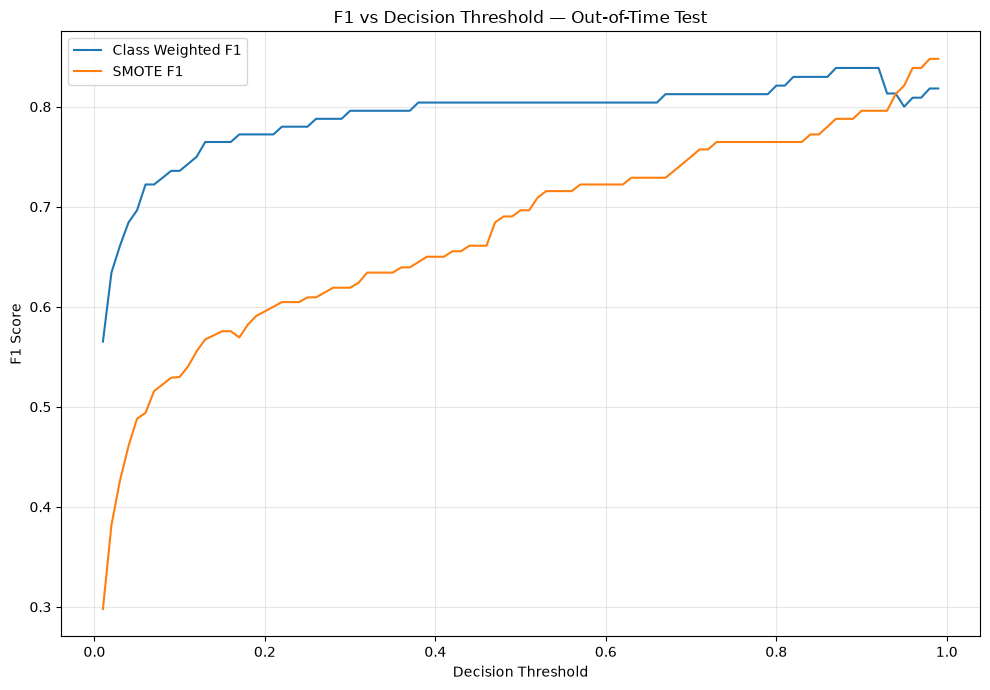

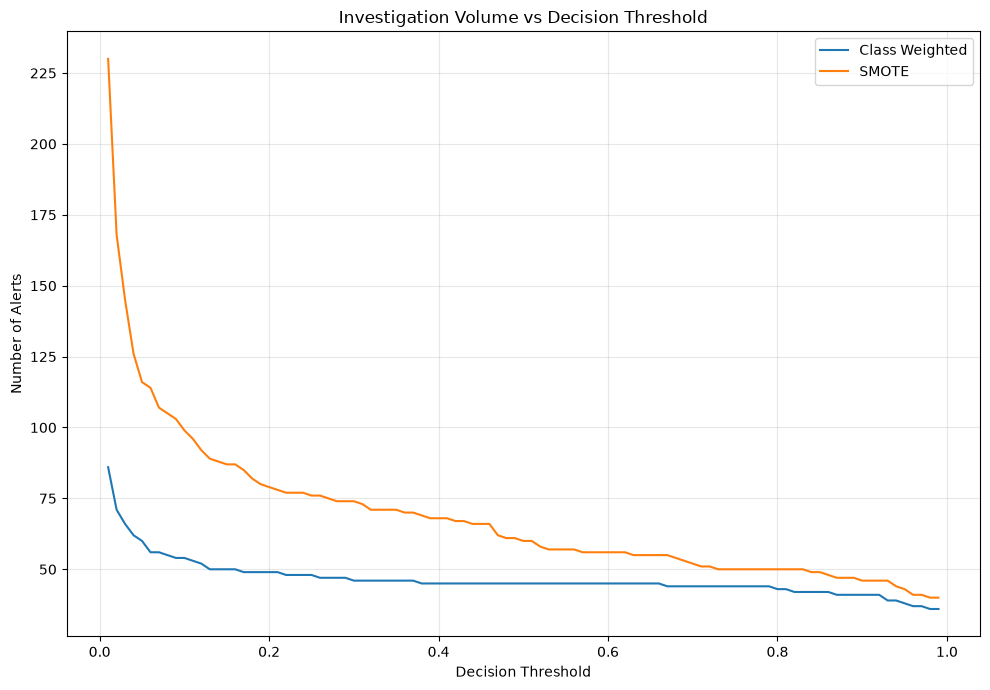


CAPACITY-CONSTRAINED PERFORMANCE
 Capacity  Weighted_Threshold  Weighted_Recall  Weighted_Precision  Weighted_F1  Weighted_Alerts  SMOTE_Threshold  SMOTE_Recall  SMOTE_Precision  SMOTE_F1  SMOTE_Alerts
       10                 NaN              NaN                 NaN          NaN              NaN              NaN           NaN              NaN       NaN           NaN
       25                 NaN              NaN                 NaN          NaN              NaN              NaN           NaN              NaN       NaN           NaN
       50                0.87             0.75             0.95122      0.83871             41.0             0.98          0.75            0.975  0.847826          40.0
      100                0.87             0.75             0.95122      0.83871             41.0             0.98          0.75            0.975  0.847826          40.0
      250                0.87             0.75             0.95122      0.83871             41.0             0.98        

In [1]:
# ============================================================
# PHASE 8 — SMOTE vs CLASS-WEIGHTED XGBOOST
# Credit Card Fraud Decision Engine
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier


# ============================================================
# 1. PATHS
# ============================================================

DATA_PATH = Path("../data/creditcard.csv")
REPORTS_PATH = Path("../reports")

REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH.resolve())
print("Reports path:", REPORTS_PATH.resolve())


# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)

print("\nDataset shape:", df.shape)


# ============================================================
# 3. SORT CHRONOLOGICALLY
# ============================================================

df = df.sort_values("Time").reset_index(drop=True)


# ============================================================
# 4. TEMPORAL 70 / 15 / 15 SPLIT
# ============================================================

n = len(df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train = df.iloc[:train_end].copy()
validation = df.iloc[train_end:validation_end].copy()
test = df.iloc[validation_end:].copy()

print("\n" + "=" * 60)
print("TEMPORAL SPLIT")
print("=" * 60)

print("Train      :", train.shape)
print("Validation :", validation.shape)
print("Test       :", test.shape)


# ============================================================
# 5. FEATURES / TARGET
# ============================================================

X_train = train.drop(columns=["Class"])
y_train = train["Class"]

X_validation = validation.drop(columns=["Class"])
y_validation = validation["Class"]

X_test = test.drop(columns=["Class"])
y_test = test["Class"]


# ============================================================
# 6. ORIGINAL CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 60)
print("ORIGINAL TRAINING CLASS DISTRIBUTION")
print("=" * 60)

print(y_train.value_counts())
print("\nFraud rate:", y_train.mean())


# ============================================================
# 7. TRAIN MODEL A — CLASS-WEIGHTED XGBOOST
# ============================================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("\nClass weight:")
print("scale_pos_weight =", scale_pos_weight)


model_weighted = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="aucpr",

    scale_pos_weight=scale_pos_weight,

    tree_method="hist",
    random_state=42,
    n_jobs=-1
)


print("\nTraining Model A — Class Weighted XGBoost...")

model_weighted.fit(
    X_train,
    y_train
)

print("Model A complete.")


# ============================================================
# 8. MODEL A PREDICTIONS
# ============================================================

weighted_validation_prob = model_weighted.predict_proba(
    X_validation
)[:, 1]

weighted_test_prob = model_weighted.predict_proba(
    X_test
)[:, 1]


# ============================================================
# 9. APPLY SMOTE — TRAINING DATA ONLY
# ============================================================

print("\n" + "=" * 60)
print("APPLYING SMOTE")
print("=" * 60)

print("\nBefore SMOTE:")

print(
    pd.Series(y_train).value_counts()
)


smote = SMOTE(
    sampling_strategy=1.0,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)


print("\nAfter SMOTE:")

print(
    pd.Series(y_train_smote).value_counts()
)

print(
    "\nOriginal training rows:",
    len(X_train)
)

print(
    "SMOTE training rows   :",
    len(X_train_smote)
)

print(
    "\nValidation rows:",
    len(X_validation)
)

print(
    "Test rows:",
    len(X_test)
)


# ============================================================
# 10. TRAIN MODEL B — SMOTE XGBOOST
# ============================================================

model_smote = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="aucpr",

    # IMPORTANT:
    # No class weighting here.
    # SMOTE is doing the balancing.
    scale_pos_weight=1,

    tree_method="hist",
    random_state=42,
    n_jobs=-1
)


print("\nTraining Model B — SMOTE XGBoost...")

model_smote.fit(
    X_train_smote,
    y_train_smote
)

print("Model B complete.")


# ============================================================
# 11. MODEL B PREDICTIONS
# ============================================================

smote_validation_prob = model_smote.predict_proba(
    X_validation
)[:, 1]

smote_test_prob = model_smote.predict_proba(
    X_test
)[:, 1]


# ============================================================
# 12. EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    y_true,
    probabilities,
    threshold=0.50
):

    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    return {
        "PR_AUC": average_precision_score(
            y_true,
            probabilities
        ),

        "ROC_AUC": roc_auc_score(
            y_true,
            probabilities
        ),

        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "True_Negatives": tn,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp,

        "Alerts": int(predictions.sum())
    }


# ============================================================
# 13. EVALUATE BOTH MODELS
# ============================================================

weighted_validation = evaluate_model(
    y_validation,
    weighted_validation_prob
)

weighted_test = evaluate_model(
    y_test,
    weighted_test_prob
)

smote_validation = evaluate_model(
    y_validation,
    smote_validation_prob
)

smote_test = evaluate_model(
    y_test,
    smote_test_prob
)


# ============================================================
# 14. COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame([
    {
        "Model": "Class Weighted XGBoost",
        "Dataset": "Validation",
        **weighted_validation
    },

    {
        "Model": "Class Weighted XGBoost",
        "Dataset": "Test",
        **weighted_test
    },

    {
        "Model": "SMOTE XGBoost",
        "Dataset": "Validation",
        **smote_validation
    },

    {
        "Model": "SMOTE XGBoost",
        "Dataset": "Test",
        **smote_test
    }
])


print("\n" + "=" * 60)
print("SMOTE VS CLASS WEIGHTING")
print("=" * 60)

print(
    comparison[
        [
            "Model",
            "Dataset",
            "PR_AUC",
            "ROC_AUC",
            "Precision",
            "Recall",
            "F1",
            "Alerts"
        ]
    ].to_string(index=False)
)


# ============================================================
# 15. SAVE COMPARISON
# ============================================================

comparison.to_csv(
    REPORTS_PATH / "smote_vs_weighted_comparison.csv",
    index=False
)

print(
    "\nSaved:",
    REPORTS_PATH /
    "smote_vs_weighted_comparison.csv"
)


# ============================================================
# 16. PR-AUC COMPARISON
# ============================================================

plt.figure(figsize=(8, 6))

models = [
    "Class Weighted",
    "SMOTE"
]

test_pr_auc_values = [
    weighted_test["PR_AUC"],
    smote_test["PR_AUC"]
]

plt.bar(
    models,
    test_pr_auc_values
)

plt.ylabel("Test PR-AUC")

plt.title(
    "Out-of-Time Test PR-AUC: SMOTE vs Class Weighting"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    REPORTS_PATH /
    "smote_vs_weighted_pr_auc.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 17. PRECISION / RECALL COMPARISON
# ============================================================

metrics = [
    "Precision",
    "Recall",
    "F1"
]

weighted_values = [
    weighted_test["Precision"],
    weighted_test["Recall"],
    weighted_test["F1"]
]

smote_values = [
    smote_test["Precision"],
    smote_test["Recall"],
    smote_test["F1"]
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    x - width / 2,
    weighted_values,
    width,
    label="Class Weighted"
)

plt.bar(
    x + width / 2,
    smote_values,
    width,
    label="SMOTE"
)

plt.xticks(
    x,
    metrics
)

plt.ylabel("Score")

plt.title(
    "Out-of-Time Test Precision / Recall / F1"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    REPORTS_PATH /
    "smote_vs_weighted_precision_recall.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 18. THRESHOLD SWEEP
# ============================================================

thresholds = np.arange(
    0.01,
    1.00,
    0.01
)


threshold_results = []


for threshold in thresholds:

    weighted_eval = evaluate_model(
        y_test,
        weighted_test_prob,
        threshold
    )

    smote_eval = evaluate_model(
        y_test,
        smote_test_prob,
        threshold
    )

    threshold_results.append({
        "Threshold": threshold,

        "Weighted_Precision":
            weighted_eval["Precision"],

        "Weighted_Recall":
            weighted_eval["Recall"],

        "Weighted_F1":
            weighted_eval["F1"],

        "Weighted_Alerts":
            weighted_eval["Alerts"],

        "SMOTE_Precision":
            smote_eval["Precision"],

        "SMOTE_Recall":
            smote_eval["Recall"],

        "SMOTE_F1":
            smote_eval["F1"],

        "SMOTE_Alerts":
            smote_eval["Alerts"]
    })


threshold_df = pd.DataFrame(
    threshold_results
)


# ============================================================
# 19. BEST F1 THRESHOLDS
# ============================================================

best_weighted_row = threshold_df.loc[
    threshold_df["Weighted_F1"].idxmax()
]

best_smote_row = threshold_df.loc[
    threshold_df["SMOTE_F1"].idxmax()
]


print("\n" + "=" * 60)
print("BEST TEST F1 THRESHOLDS")
print("=" * 60)

print("\nClass Weighted XGBoost")

print(
    f"Threshold : "
    f"{best_weighted_row['Threshold']:.2f}"
)

print(
    f"Precision : "
    f"{best_weighted_row['Weighted_Precision']:.4f}"
)

print(
    f"Recall    : "
    f"{best_weighted_row['Weighted_Recall']:.4f}"
)

print(
    f"F1        : "
    f"{best_weighted_row['Weighted_F1']:.4f}"
)

print(
    f"Alerts    : "
    f"{int(best_weighted_row['Weighted_Alerts'])}"
)


print("\nSMOTE XGBoost")

print(
    f"Threshold : "
    f"{best_smote_row['Threshold']:.2f}"
)

print(
    f"Precision : "
    f"{best_smote_row['SMOTE_Precision']:.4f}"
)

print(
    f"Recall    : "
    f"{best_smote_row['SMOTE_Recall']:.4f}"
)

print(
    f"F1        : "
    f"{best_smote_row['SMOTE_F1']:.4f}"
)

print(
    f"Alerts    : "
    f"{int(best_smote_row['SMOTE_Alerts'])}"
)


# ============================================================
# 20. SAVE THRESHOLD COMPARISON
# ============================================================

threshold_df.to_csv(
    REPORTS_PATH /
    "smote_vs_weighted_thresholds.csv",
    index=False
)

print(
    "\nSaved:",
    REPORTS_PATH /
    "smote_vs_weighted_thresholds.csv"
)


# ============================================================
# 21. THRESHOLD PERFORMANCE PLOT
# ============================================================

plt.figure(figsize=(10, 7))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Weighted_F1"],
    label="Class Weighted F1"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["SMOTE_F1"],
    label="SMOTE F1"
)

plt.xlabel("Decision Threshold")

plt.ylabel("F1 Score")

plt.title(
    "F1 vs Decision Threshold — Out-of-Time Test"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    REPORTS_PATH /
    "smote_vs_weighted_f1_threshold.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 22. ALERT VOLUME VS THRESHOLD
# ============================================================

plt.figure(figsize=(10, 7))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Weighted_Alerts"],
    label="Class Weighted"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["SMOTE_Alerts"],
    label="SMOTE"
)

plt.xlabel("Decision Threshold")

plt.ylabel("Number of Alerts")

plt.title(
    "Investigation Volume vs Decision Threshold"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    REPORTS_PATH /
    "smote_vs_weighted_alert_volume.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 23. CAPACITY-CONSTRAINED COMPARISON
# ============================================================

capacities = [
    10,
    25,
    50,
    100,
    250,
    500
]

capacity_results = []


for capacity in capacities:

    weighted_possible = threshold_df[
        threshold_df["Weighted_Alerts"] <= capacity
    ]

    smote_possible = threshold_df[
        threshold_df["SMOTE_Alerts"] <= capacity
    ]


    # --------------------------------------------------------
    # Weighted model
    # --------------------------------------------------------

    if len(weighted_possible) > 0:

        weighted_best = weighted_possible.loc[
            weighted_possible["Weighted_F1"].idxmax()
        ]

        weighted_threshold = weighted_best[
            "Threshold"
        ]

        weighted_recall = weighted_best[
            "Weighted_Recall"
        ]

        weighted_precision = weighted_best[
            "Weighted_Precision"
        ]

        weighted_f1 = weighted_best[
            "Weighted_F1"
        ]

        weighted_alerts = weighted_best[
            "Weighted_Alerts"
        ]

    else:

        weighted_threshold = np.nan
        weighted_recall = np.nan
        weighted_precision = np.nan
        weighted_f1 = np.nan
        weighted_alerts = np.nan


    # --------------------------------------------------------
    # SMOTE model
    # --------------------------------------------------------

    if len(smote_possible) > 0:

        smote_best = smote_possible.loc[
            smote_possible["SMOTE_F1"].idxmax()
        ]

        smote_threshold = smote_best[
            "Threshold"
        ]

        smote_recall = smote_best[
            "SMOTE_Recall"
        ]

        smote_precision = smote_best[
            "SMOTE_Precision"
        ]

        smote_f1 = smote_best[
            "SMOTE_F1"
        ]

        smote_alerts = smote_best[
            "SMOTE_Alerts"
        ]

    else:

        smote_threshold = np.nan
        smote_recall = np.nan
        smote_precision = np.nan
        smote_f1 = np.nan
        smote_alerts = np.nan


    capacity_results.append({

        "Capacity": capacity,

        "Weighted_Threshold":
            weighted_threshold,

        "Weighted_Recall":
            weighted_recall,

        "Weighted_Precision":
            weighted_precision,

        "Weighted_F1":
            weighted_f1,

        "Weighted_Alerts":
            weighted_alerts,

        "SMOTE_Threshold":
            smote_threshold,

        "SMOTE_Recall":
            smote_recall,

        "SMOTE_Precision":
            smote_precision,

        "SMOTE_F1":
            smote_f1,

        "SMOTE_Alerts":
            smote_alerts
    })


capacity_df = pd.DataFrame(
    capacity_results
)


print("\n" + "=" * 60)
print("CAPACITY-CONSTRAINED PERFORMANCE")
print("=" * 60)

print(
    capacity_df.to_string(index=False)
)


capacity_df.to_csv(
    REPORTS_PATH /
    "smote_vs_weighted_capacity.csv",
    index=False
)

print(
    "\nSaved:",
    REPORTS_PATH /
    "smote_vs_weighted_capacity.csv"
)


# ============================================================
# 24. DETERMINE CHAMPION MODEL
#
# Primary metric = TEST PR-AUC
# Secondary consideration = F1 / operational behavior
# ============================================================

weighted_pr_auc = weighted_test["PR_AUC"]
smote_pr_auc = smote_test["PR_AUC"]


if weighted_pr_auc >= smote_pr_auc:

    champion_model = "Class Weighted XGBoost"
    champion_reason = (
        "Higher or equal out-of-time test PR-AUC."
    )

else:

    champion_model = "SMOTE XGBoost"
    champion_reason = (
        "Higher out-of-time test PR-AUC."
    )


print("\n" + "=" * 60)
print("CHAMPION MODEL")
print("=" * 60)

print(
    "\nChampion:",
    champion_model
)

print(
    "Reason:",
    champion_reason
)


# ============================================================
# 25. SAVE CHAMPION SUMMARY
# ============================================================

champion_summary = pd.DataFrame([{

    "Champion_Model": champion_model,

    "Reason": champion_reason,

    "Weighted_Test_PR_AUC":
        weighted_pr_auc,

    "SMOTE_Test_PR_AUC":
        smote_pr_auc,

    "Weighted_Test_ROC_AUC":
        weighted_test["ROC_AUC"],

    "SMOTE_Test_ROC_AUC":
        smote_test["ROC_AUC"],

    "Weighted_Test_Precision":
        weighted_test["Precision"],

    "SMOTE_Test_Precision":
        smote_test["Precision"],

    "Weighted_Test_Recall":
        weighted_test["Recall"],

    "SMOTE_Test_Recall":
        smote_test["Recall"],

    "Weighted_Test_F1":
        weighted_test["F1"],

    "SMOTE_Test_F1":
        smote_test["F1"]

}])


champion_summary.to_csv(
    REPORTS_PATH /
    "phase8_champion_summary.csv",
    index=False
)


# ============================================================
# 26. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("PHASE 8 COMPLETE")
print("=" * 70)

print("\nGenerated reports:")

files_created = [

    "smote_vs_weighted_comparison.csv",

    "smote_vs_weighted_pr_auc.png",

    "smote_vs_weighted_precision_recall.png",

    "smote_vs_weighted_thresholds.csv",

    "smote_vs_weighted_f1_threshold.png",

    "smote_vs_weighted_alert_volume.png",

    "smote_vs_weighted_capacity.csv",

    "phase8_champion_summary.csv"
]

for filename in files_created:

    path = REPORTS_PATH / filename

    if path.exists():

        print("✓", filename)

    else:

        print("—", filename, "(not generated)")


print("\n")
print("Next step:")
print("Use the actual Phase 8 results to select the final")
print("fraud detection model before building the final")
print("decision + drift monitoring architecture.")